Tested with:
- Python 3.13.9
- numpy 2.4.4
- pandas 2.3.3
- scikit-learn 1.7.2
- rdkit 2026.3.1
- schnetpack 2.2.0
- ase 3.26.0
- scikit-activeml 1.0.0
- skorch 1.3.1

Visualisation:
- umap-learn 0.5.12
- datashader 0.19.1
- bokeh 3.9.0
- holoviews 1.22.1
- scikit-image 0.26.0
- colorcet 3.2.1

In [39]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import skactiveml
from joblib import Parallel, delayed
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, rdMolDescriptors, rdFingerprintGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Config
CSV_PATH = '../data/qm9/raw/gdb9.sdf.csv'
SDF_PATH = '../data/qm9/raw/gdb9.sdf'
SMILES_COL = 'smiles'
TARGET_COL = 'gap'
MORGAN_RADIUS = 2
MORGAN_BITS = 2048

# Do NOT include 'homo' or 'lumo' here — gap = lumo - homo (leakage!)
# Do NOT include thermodynamic properties u0, u298, h298, g298, if one of them is target
BLACKLIST_COLS = [SMILES_COL, TARGET_COL, 'mol_id', 'Unnamed: 0', 'mol', 'lumo', 'homo']
qm9_features_full = ['mu', 'alpha', 'homo', 'lumo', 'gap', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv']
qm9_features = [c for c in qm9_features_full if c not in BLACKLIST_COLS]

def fps_from_smiles(smiles):
    '''
    Build one RDKit molecule from SMILES and compute Moragan and MACCSkeys fingerprints.

    Args:
        smiles: SMILES string (str).
    '''
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')

    gen = rdFingerprintGenerator.GetMorganGenerator(radius=MORGAN_RADIUS, fpSize=MORGAN_BITS) #create Morgan generator
    
    morgan_fp = np.array(gen.GetFingerprintAsNumPy(mol), dtype=np.float32)
    maccs_fp = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
    
    return morgan_fp, maccs_fp

def compute_fingerprints_parallel(smiles_list, n_jobs=-1):
    '''
    Compute Morgan + MACCS fingerprints in parallel.

    Args:
        smiles_list: list of SMILES strings (list[str])
        n_jobs: number of worker processes (-1 = all cores)

    Returns:
        morgan: np.ndarray
        maccs: np.ndarray
    '''
    fps = Parallel(n_jobs=n_jobs, backend='loky', batch_size='auto')(delayed(fps_from_smiles)(smiles) for smiles in smiles_list)

    morgan, maccs = zip(*fps)
    return np.stack(morgan), np.stack(maccs)
    
def build_X(df, scaler=StandardScaler(), train=False, raw=False, n_jobs=-1):
    '''
    Build X with scaled continuous part and fingerprints.

    Args:
        df: dataframe with a 'smiles' column and qm9_features columns
        scaler: fitted scaler, or None to create a StandardScaler
        train: if True, fit scaler on continuous features
        raw: if True, return unscaled X
        n_jobs: number of CPU cores to use for fingerprinting (-1 = all)

    Returns:
        X: feature matrix
    '''
    df = df.copy()
    smiles_list = df['smiles'].tolist()    
    morgan, maccs = compute_fingerprints_parallel(smiles_list, n_jobs=n_jobs)
    continuous = df[qm9_features].to_numpy()

    if raw:
        return np.hstack([continuous, morgan, maccs])

    continuous = (
        scaler.fit_transform(continuous)
        if train
        else scaler.transform(continuous)
    )

    return np.hstack([continuous, morgan, maccs])

def plot_prediction(X, y, model, model_name=None, name=TARGET_COL, figsize=(6, 6), save=None, format='pdf'):
    '''
    Plot predictions for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        model_name: Name of the model (str).
        name: Name of the target value (str).
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    y_pred = model.predict(X)
    errors = np.abs(y - y_pred)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y, y_pred, c=errors, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {name}')
    ax.set_ylabel(f'predicted {name}')
    if model_name is None:
        ax.set_title(f'{name} {model.__class__.__name__} prediction plot')
    else:
        ax.set_title(f'{name} {model_name} prediction plot')
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mean_absolute_error(y,y_pred):.4f}')
    print(f'MSE = {mean_squared_error(y,y_pred):.4f}')
    print(f'RMSE = {root_mean_squared_error(y,y_pred):.4f}')
    print(f'r^2 = {r2_score(y,y_pred):.4f}')

def print_cross_val(X, y, model, splits=5, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        n_splits: Number of CV splits (int).
        random_state: Random state seed (int).
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    cv = KFold(n_splits=splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
        'mae':  'neg_mean_absolute_error',
        'mse':  'neg_mean_sqared_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2',
    }
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring_metrics)

    print('Cross-validation scores:')
    print(f'Mean MAE  = {np.mean(np.abs(results['test_mae'])):.4f}')
    print(f'Mean MSE  = {np.mean(np.abs(results['test_mse'])):.4f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.4f}')
    print(f'Mean R²   = {np.mean(results['test_r2']):.4f}')

def plot_violin(X, y, models, metric='rmse', target_name=TARGET_COL, splits=5, y_min=0, y_max=None, figsize=(10, 6)):
    '''
    Plot RMSE violin plot for given models and data.

    Args:
        X           : Input features (np.array).
        y           : True target values (np.array).
        models      : List of unfitted model instances (list).
        target_name : Label for plot title (str).
        splits      : Number of CV splits (int).
        y_min       : Y-axis min value (float).
        y_max       : Y-axis max value (float).
        metric      : 'rsr' or 'rmse' (str)
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    records = []
    for model in models:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model),
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        if metric == 'rmse':
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RMSE': -score})
        else:
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RSR': -score/y.std()})
                
    df_plot = pd.dataFrame(records)

    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(
        data=df_plot,
        y='RMSE' if metric == 'rmse' else 'RSR',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    ax.set_title(f'{target_name}\nModel Comparison — CV RMSE Scores' if metric == 'rmse' else f'{target_name}\nModel Comparison — CV RSR Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_feature_importances(model, qm9_features=qm9_features, top_n=20, morgan_bits=2048, maccs_bits=167, figsize=(10, 6)):
    '''
    Plot top-N aggregated feature importances for an RF trained on:
    [QM9 | Morgan FP (aggregated) | MACCS keys (aggregated)]

    Args:
        model:         Fitted model.
        qm9_features:  QM9 feature names (list).
        top_n:         Number of features to display (int).
        morgan_bits:   Morgan FP length (int).
        maccs_bits:    MACCS key length (int).
        figsize:       Figure size (tuple).

    Returns:
        pd.Series of aggregated importances, sorted descending.
    '''
    feature_names = (
        list(qm9_features)
        + ['Morgan_FP'] * morgan_bits
        + ['MACCS_Keys'] * maccs_bits
    )

    importances = model.feature_importances_
    
    if len(importances) != len(feature_names):
        raise ValueError(
            f'Feature count mismatch: model has {len(importances)}, '
            f'expected {len(feature_names)} '
            f'({len(qm9_features)} QM9'
            f'+ {morgan_bits} Morgan + {maccs_bits} MACCS).'
        )

    agg: pd.Series = (
        pd.Series(importances, index=feature_names)
        .groupby(level=0)
        .sum()
        .sort_values(ascending=False)
    )

    top = agg.head(top_n)

    fig, ax = plt.subplots(figsize=figsize)
    top.iloc[::-1].plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Summed Feature Importance')
    ax.set_title(f'Top {top_n} Feature Importances')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return agg

In [ ]:
# 95% OOD split (HOMO-LUMO gap)
df = pd.read_csv('data/qm9_full.csv')
df = df.drop(columns=['Unnamed: 0'])

threshold = df['gap'].quantile(0.95)
print(f'Threshold for OOD (95th percentile): {threshold:.4f}')

ood_df = df[df['gap'] >= threshold].copy()

id_df = df[df['gap'] < threshold].copy()

# 1. Split 80% train, 20% temp
strat_bins = pd.qcut(id_df['gap'], q=10, labels=False)
id_df_train, id_df_temp = train_test_split(id_df, test_size=0.2, stratify=strat_bins, random_state=42)

# 2. Split temp 50/50 to get 10% test, 10% val
temp_bins = pd.qcut(id_df_temp['gap'], q=10, labels=False)
id_df_test, id_df_val = train_test_split(id_df_temp, test_size=0.5, random_state=42, stratify=temp_bins)

# 3. Save to disk
ood_df.to_csv('data/qm9_ood_gap.csv', index=False)
id_df_train.to_csv('data/qm9_id_gap_train.csv', index=False)
id_df_test.to_csv('data/qm9_id_gap_test.csv', index=False)
id_df_val.to_csv('data/qm9_id_gap_val.csv', index=False)

In [2]:
# Load Sample OOD
df_train = pd.read_csv('data/ood/qm9_id_gap_train.csv')
bins_train = pd.qcut(df_train['gap'], q=10, labels=False)
_, df_train = train_test_split(df_train, test_size=0.02, stratify=bins_train, random_state=42)

df_test = pd.read_csv('data/ood/qm9_id_gap_test.csv')
bins_test = pd.qcut(df_test['gap'], q=10, labels=False)
_, df_test = train_test_split(df_test, test_size=0.02, stratify=bins_test, random_state=42)

df_val = pd.read_csv('data/ood/qm9_id_gap_val.csv')
bins_val = pd.qcut(df_val['gap'], q=10, labels=False)
_, df_val = train_test_split(df_val, test_size=0.02, stratify=bins_val, random_state=42)

df_ood = pd.read_csv('data/ood/qm9_ood_gap.csv')
bins_ood = pd.qcut(df_ood['gap'], q=10, labels=False)
_, df_ood = train_test_split(df_ood, test_size=0.04, stratify=bins_ood, random_state=42)


rdkit_features = [d[0] for d in Descriptors.descList]
qm9_features = [c for c in list(df_train.columns) if c not in BLACKLIST_COLS and c not in rdkit_features]

def build_X(df, scaler = StandardScaler(), train=False, raw=False):
    '''
    Build X with scaled continuous part and fingerprints.
    If raw=True, returns unscaled X (for use in CV pipeline).
    '''
    df = df.copy()
    df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
    morgan     = np.stack(df['mol'].apply(morgan_fp).values)
    maccs      = np.stack(df['mol'].apply(maccs_fp).values)
    continuous = np.hstack([df[qm9_features].values, df[rdkit_features].values])

    if raw:
        return np.hstack([continuous, morgan, maccs])

    continuous = scaler.fit_transform(continuous) if train else scaler.transform(continuous)
    return np.hstack([continuous, morgan, maccs])
    
X_train = build_X(df_train, train=True)
X_test = build_X(df_test)
X_val = build_X(df_val)
X_ood = build_X(df_ood)

y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values
y_val = df_val[TARGET_COL].values
y_ood = df_ood[TARGET_COL].values

print(f'Train set Molecules: {X_train.shape[0]}  |  Features: {X_train.shape[1]}')
print(f'Test set Molecules: {X_test.shape[0]}  |  Features: {X_test.shape[1]}')
print(f'Validate set Molecules: {X_val.shape[0]}  |  Features: {X_val.shape[1]}')
print(f'OOD set Molecules: {X_ood.shape[0]}  |  Features: {X_ood.shape[1]}')

Train set Molecules: 2394  |  Features: 2441
Test set Molecules: 300  |  Features: 2441
Validate set Molecules: 300  |  Features: 2441
OOD set Molecules: 316  |  Features: 2441


In [6]:
# Load
df_train = pd.read_csv('../data/qm9/gap/qm9_gap_train.csv')
df_test = pd.read_csv('../data/qm9/gap/qm9_gap_test.csv')
df_val = pd.read_csv('../data/qm9/gap/qm9_gap_val.csv')
# df = pd.read_csv('../data/qm9/qm9.csv')

X_train = build_X(df_train, train=True)
X_test = build_X(df_test)
X_val = build_X(df_val)
# X_cv = build_X(df_train, raw=True)
# X = build_X(df, raw=True)

y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values
y_val = df_val[TARGET_COL].values
# y = df[TARGET_COL].values

print(f'Train set Molecules: {X_train.shape[0]}  |  Features: {X_train.shape[1]}')
print(f'Test set Molecules: {X_test.shape[0]}  |  Features: {X_test.shape[1]}')
print(f'Validate set Molecules: {X_val.shape[0]}  |  Features: {X_val.shape[1]}')
# print(f'Full set Molecules: {X.shape[0]}  |  Features: {X.shape[1]}')

Train set Molecules: 107106  |  Features: 2223
Test set Molecules: 13389  |  Features: 2223
Validate set Molecules: 13386  |  Features: 2223


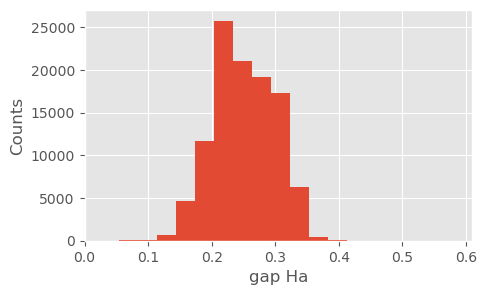

In [23]:
# Plot train histogram
plt.figure(figsize=(5,3))
plt.hist(df_train['gap'], bins=20)
plt.xlabel(r'gap Eh')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

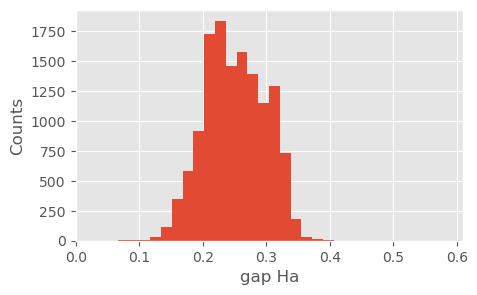

In [20]:
# Plot test histogram
plt.figure(figsize=(5,3))
plt.hist(df_test['gap'], bins=20)
plt.xlabel(r'gap Eh')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

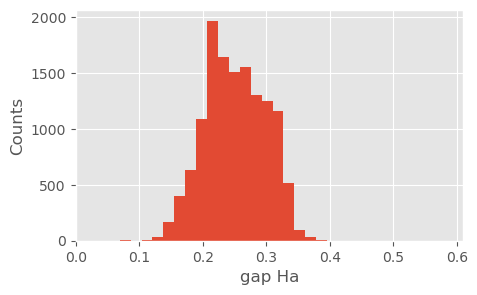

In [24]:
# Plot val histogram
plt.figure(figsize=(5,3))
plt.hist(df_val['gap'], bins=20)
plt.xlabel(r'gap Eh')
plt.ylabel('Counts')
plt.xlim(0, 0.61)
plt.show()

## Baseline

### Train models

In [3]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
joblib.dump(rf, 'models/rf/qm9/rf_gap_qm9.pkl')

['models/rf/qm9/rf_gap_qm9.pkl']

In [4]:
# from sklearn.kernel_ridge import KernelRidge
# kr = KernelRidge(
#     alpha=0.01,
#     gamma=0.0001,
#     kernel='laplacian',
# )

from sklearn.kernel_approximation import Nystroem # Approximate a kernel map using a subset of the training data, KRR on QM9 is computationally infeasible
from sklearn.linear_model import Ridge
kr = Pipeline([
    ('nystroem', Nystroem(
        kernel='laplacian', 
        n_components=2500,
        gamma=0.01,          # This is the most important hyperparameter to tune
        n_jobs=-1,
        random_state=42,
    )),
    ('ridge', Ridge(alpha=0.01))
])
kr.fit(X_train,y_train)
joblib.dump(kr, 'models/kr/qm9/kr_gap_qm9.pkl')

['models/kr/qm9/kr_gap_qm9.pkl']

In [5]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.6,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=3,
    n_estimators=100,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    n_job=-1,
)
xgb.fit(X_train,y_train)
joblib.dump(xgb, 'models/xgb/qm9/xgb_gap_qm9.pkl')

['models/xgb/qm9/xgb_gap_qm9.pkl']

In [ ]:
from sklearn.ensemble import VotingRegressor
com = VotingRegressor(
    estimators=[
        ('rf', clone(rf)),
        ('xgb', clone(xgb)),
        ('kr', clone(kr)),
    ],
    n_jobs=-1,
)
com.fit(X_train,y_train)
joblib.dump(com, 'models/com/qm9/com_gap_qm9.pkl')

### Load models

In [7]:
rf = joblib.load('models/rf/qm9/rf_gap_qm9.pkl') #RandomForestRegressor
kr = joblib.load('models/kr/qm9/kr_gap_qm9.pkl') #Nystroem+Ridge
xgb= joblib.load('models/xgb/qm9/xgb_gap_qm9.pkl') #XGBRegressor
com= joblib.load('models/com/qm9/com_gap_qm9.pkl') #Committee VotingRegressor of models above

In [8]:
# Score of the model
rf_pred_test = rf.predict(X_test)
rf_pred_val = rf.predict(X_val)
rf_score = {
    'mae_test': mean_absolute_error(y_test, rf_pred_test),
    'rmse_test': root_mean_squared_error(y_test, rf_pred_test),
    'r2_test':  r2_score(y_test, rf_pred_test),
    'mae_val': mean_absolute_error(y_val, rf_pred_val),
    'rmse_val':  root_mean_squared_error(y_val, rf_pred_val),
    'r2_val':   r2_score(y_val, rf_pred_val),
}
print(rf_score)

kr_pred_test = kr.predict(X_test)
kr_pred_val = kr.predict(X_val)
kr_score = {
    'mae_test': mean_absolute_error(y_test, kr_pred_test),
    'rmse_test': root_mean_squared_error(y_test, kr_pred_test),
    'r2_test': r2_score(y_test, kr_pred_test),
    'mae_val': mean_absolute_error(y_val, kr_pred_val),
    'rmse_val': root_mean_squared_error(y_val, kr_pred_val),
    'r2_val': r2_score(y_val, kr_pred_val),
}
print(kr_score)

xgb_pred_test = xgb.predict(X_test)
xgb_pred_val = xgb.predict(X_val)
xgb_score = {
    'mae_test': mean_absolute_error(y_test, xgb_pred_test),
    'rmse_test': root_mean_squared_error(y_test, xgb_pred_test),
    'r2_test': r2_score(y_test, xgb_pred_test),
    'mae_val': mean_absolute_error(y_val, xgb_pred_val),
    'rmse_val': root_mean_squared_error(y_val, xgb_pred_val),
    'r2_val': r2_score(y_val, xgb_pred_val),
}
print(xgb_score)

com_pred_test = com.predict(X_test)
com_pred_val = com.predict(X_val)
com_score = {
    'mae_test': mean_absolute_error(y_test, com_pred_test),
    'rmse_test': root_mean_squared_error(y_test, com_pred_test),
    'r2_test': r2_score(y_test, com_pred_test),
    'mae_val': mean_absolute_error(y_val, com_pred_val),
    'rmse_val': root_mean_squared_error(y_val, com_pred_val),
    'r2_val': r2_score(y_val, com_pred_val),
}
print(com_score)


{'mae_test': 0.009924058167476928, 'rmse_test': 0.013231580912337492, 'r2_test': 0.9223674653676215, 'mae_val': 0.010001891686834808, 'rmse_val': 0.013358104084908787, 'r2_val': 0.9207016021073378}
{'mae_test': 0.010004360977698875, 'rmse_test': 0.013091143145577591, 'r2_test': 0.9240066770392797, 'mae_val': 0.01008076485063601, 'rmse_val': 0.013192981458632553, 'r2_val': 0.9226499371253309}
{'mae_test': 0.011282817141391297, 'rmse_test': 0.014717751291643736, 'r2_test': 0.9039487079190631, 'mae_val': 0.011398566662196566, 'rmse_val': 0.014870194421175402, 'r2_val': 0.9017329179156723}
{'mae_test': 0.00944870294082709, 'rmse_test': 0.01243808426491014, 'r2_test': 0.9313994999565665, 'mae_val': 0.009561863681689391, 'rmse_val': 0.012584439658682677, 'r2_val': 0.9296210906642849}


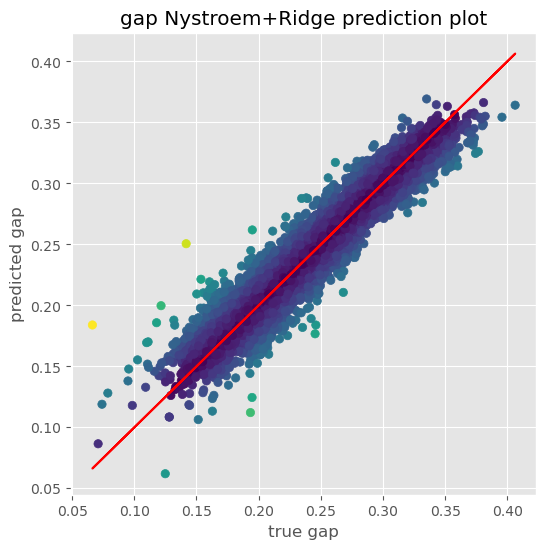

Training scores:
MAE = 0.0100
MSE = 0.0002
RMSE = 0.0131
r^2 = 0.9240


In [29]:
plot_prediction(X_test, y_test, kr, model_name='Nystroem+Ridge', save='models/kr/qm9/kr_gap_qm9_plot.png', format='png')

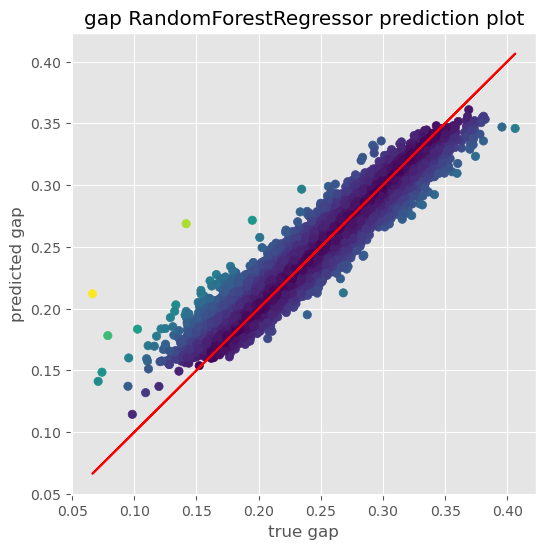

Training scores:
MAE = 0.0099
MSE = 0.0002
RMSE = 0.0132
r^2 = 0.9224


In [30]:
plot_prediction(X_test, y_test, rf, save='models/rf/qm9/rf_gap_qm9_plot.png', format='png')

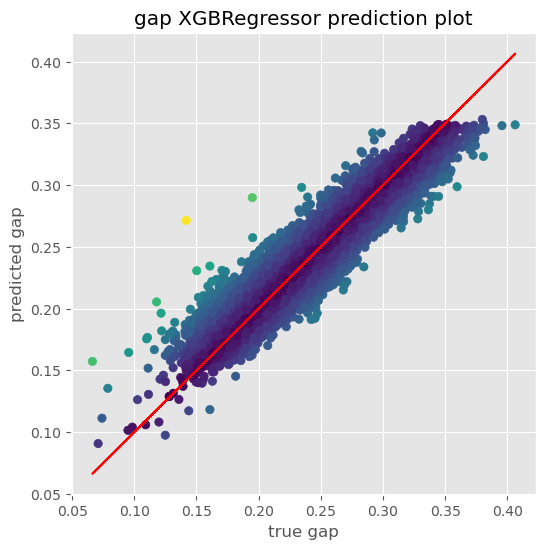

Training scores:
MAE = 0.0113
MSE = 0.0002
RMSE = 0.0147
r^2 = 0.9039


In [31]:
plot_prediction(X_test, y_test, xgb, save='models/xgb/qm9/xgb_gap_qm9_plot.png', format='png')

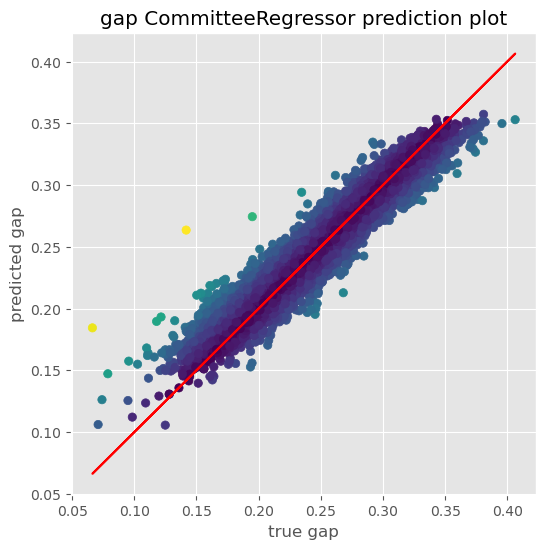

Training scores:
MAE = 0.0094
MSE = 0.0002
RMSE = 0.0124
r^2 = 0.9314


In [32]:
plot_prediction(X_test, y_test, com, model_name='CommitteeRegressor',save='models/com/qm9/com_gap_qm9_plot.png', format='png')

In [64]:
print_cross_val(X_cv, y_train, rf)

Cross-validation scores:
Mean MAE  = 0.017
Mean RMSE = 0.024
Mean R²   = 0.822


{'fit_time': array([0.50598025, 0.46400213, 0.52041268, 0.53708076, 0.48586082]),
 'score_time': array([0.14808869, 0.14795494, 0.12902164, 0.08358002, 0.12156057]),
 'test_mae': array([-0.01644799, -0.01607576, -0.01725342, -0.01606048, -0.01750535]),
 'test_rmse': array([-0.02469771, -0.02244883, -0.02539042, -0.0243015 , -0.024934  ]),
 'test_r2': array([0.8154605 , 0.85186539, 0.80695071, 0.83856857, 0.79926018])}

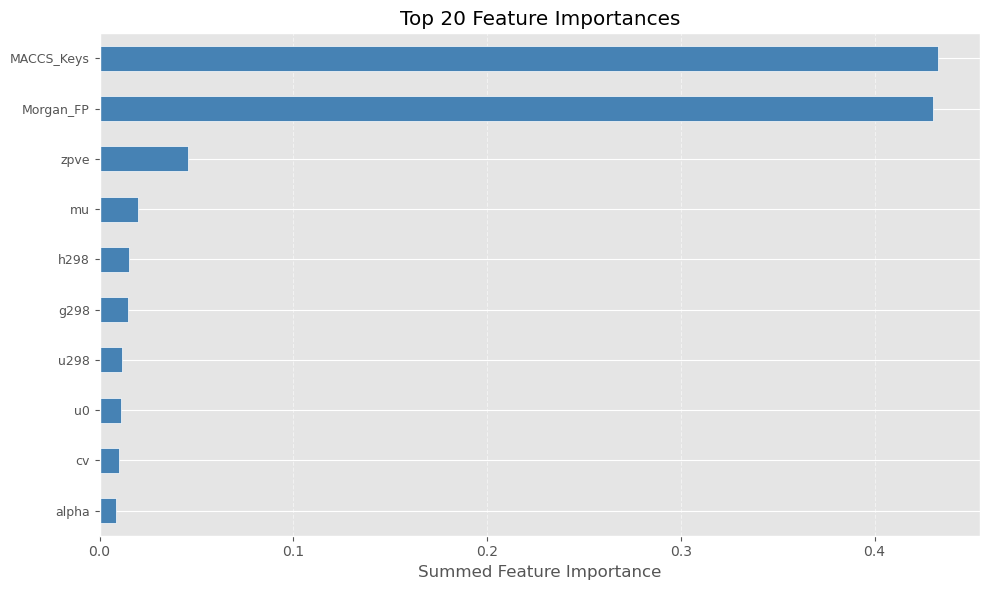

MACCS_Keys    0.432798
Morgan_FP     0.430211
zpve          0.045736
mu            0.019835
h298          0.015228
g298          0.014561
u298          0.011534
u0            0.011294
cv            0.010113
alpha         0.008690
dtype: float64

In [28]:
plot_feature_importances(rf)

# AL Query strategies

In [6]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import RandomSampling
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_rnd(
    model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Random sampling active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
                
            if len(unlabeled_idx) == 0:    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} Eh | '
                    f'RMSE: {rmse_test:.4f} Eh | '
                    f'R2: {r2_test:.4f} | '
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx = rnd.query(X=X_train, y=y_pool, batch_size=batch_size)
            
            y_pool[query_idx] = y_train[query_idx]
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} Eh | '
                f'RMSE: {rmse_test:.4f} Eh | '
                f'R2: {r2_test:.4f} | '
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [7]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_unc(
    model,
    bagging_estimators=5,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee Bagging Regressor) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        bagging_estimators: Number of estimators in the bagging committee (int).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                BaggingRegressor(
                    estimator=reg,   
                    n_estimators=bagging_estimators,
                    bootstrap=True,
                    random_state=random_state,
                )
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} Eh | '
                    f'RMSE: {rmse_test:.4f} Eh | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} Eh  '
                    f'max: {0:.4f} Eh'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} Eh | '
                f'RMSE: {rmse_test:.4f} Eh | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} Eh  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} Eh'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [8]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_qbc(
    model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee with heterogeneous models) active learning loop over a regression task.

    Args:
        models: Committee models of several base estimators (sklearn VotingRegressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                estimator=reg, random_state=random_state
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} Eh | '
                    f'RMSE: {rmse_test:.4f} Eh | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} Eh  '
                    f'max: {0:.4f} Eh'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} Eh | '
                f'RMSE: {rmse_test:.4f} Eh | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} Eh  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} Eh'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [9]:
from sklearn.base import clone
from skactiveml.regressor import SklearnRegressor
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def diversity_query(
    X_train: np.ndarray,
    y_pool: np.ndarray,
    batch_size: int,
):
    '''
    Select a batch of unlabeled samples using greedy MaxMin diversity sampling with Tanimoto distance.

    Args:
        X_train: Training feature matrix with only fingerprints (np.ndarray).
        y_pool: Current label pool. Unlabeled entries are marked with MISSING_LABEL (np.ndarray).
        batch_size: Number of samples to select (int).
    Returns:
        query_idx: Queried indices, ordered from most to least diverse (np.ndarray).
        utilities:
            - div_mean_pool: Mean Tanimoto distance of all unlabeled points to their nearest labeled neighbour.
            - div_max_pool: Maximum Tanimoto distance in the unlabeled pool, i.e. the distance of the most underexplored point.
    '''
    labeled_idx   = labeled_indices(y_pool)
    unlabeled_idx = unlabeled_indices(y_pool)

    if len(unlabeled_idx) == 0:
        return np.array([], dtype=int), {}

    actual_batch = min(batch_size, len(unlabeled_idx))

    # binarize once, float32 halves memory + speeds up BLAS
    X_u = (X_train[unlabeled_idx] > 0).astype(np.float32)
    X_l = (X_train[labeled_idx]   > 0).astype(np.float32)

    # precompute norms once — reused in every greedy step
    norms_u = X_u.sum(axis=1)  # (n_unlabeled,)
    norms_l = X_l.sum(axis=1)  # (n_labeled,)

    # initial max similarity to labeled set — single matmul
    dot   = X_u @ X_l.T                              # (n_u, n_l)
    union = norms_u[:, None] + norms_l[None, :] - dot
    np.maximum(union, 1e-10, out=union)               # in-place, no allocation
    max_sim = (dot / union).max(axis=1)               # (n_u,)
    del dot, union                                    # free memory immediately

    dist_orig = 1.0 - max_sim.copy()

    selected_local: list[int] = []

    for _ in range(actual_batch):
        best = int(np.argmin(max_sim))f
        selected_local.append(best)
        max_sim[best] = np.inf

        if len(selected_local) < actual_batch:
            # matvec (n_u × d) instead of matmul (n_u × n_u) — much cheaper
            dot_new   = X_u @ X_u[best]              # (n_u,)
            union_new = norms_u + norms_u[best] - dot_new
            np.maximum(union_new, 1e-10, out=union_new)
            np.maximum(max_sim, dot_new / union_new, out=max_sim)

    utilities = {
        'mean_diversity': float(dist_orig.mean()),
        'max_diversity':  float(dist_orig.max()),
    }

    return unlabeled_idx[np.array(selected_local)], utilities
    
def al_loop_div(
    model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Diversity sampling (Tanimoto distance) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_diversity': [],
            'max_diversity': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:    
                history['mean_diversity'].append(0.0)
                history['max_diversity'].append(0.0)
                
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} Eh | '
                    f'RMSE: {rmse_test:.4f} Eh | '
                    f'R2: {r2_test:.4f} | '
                    f'Diversity — mean: {0:.4f} Eh  '
                    f'max: {0:.4f} Eh'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx, utilities = diversity_query(X_train[:, (slice(len(qm9_features), None))], y_pool, batch_size)
            
            y_pool[query_idx] = y_train[query_idx]

            history['mean_diversity'].append(utilities['mean_diversity'])
            history['max_diversity'].append(utilities['max_diversity'])
            
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} Eh | '
                f'RMSE: {rmse_test:.4f} Eh | '
                f'R2: {r2_test:.4f} | '
                f'Diversity — mean: {utilities['mean_diversity']:.4f}  '
                f'max: {utilities['max_diversity']:.4f}'
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [7]:
al_loop_rnd(rf, n_runs=5, save='active_learning/rf/qm9/al_history_rf_rnd_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0158 Eh | RMSE: 0.0204 Eh | R2: 0.8148 | 
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0147 Eh | RMSE: 0.0192 Eh | R2: 0.8368 | 
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0138 Eh | RMSE: 0.0181 Eh | R2: 0.8545 | 
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0131 Eh | RMSE: 0.0172 Eh | R2: 0.8690 | 
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0127 Eh | RMSE: 0.0168 Eh | R2: 0.8752 | 
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0124 Eh | RMSE: 0.0165 Eh | R2: 0.8800 | 
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0119 Eh | RMSE: 0.0158 Eh | R2: 0.8891 | 
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0118 Eh | RMSE: 0.0156 Eh | R2: 0.8916 | 
Cycle  9 | Labeled: 47106/107106 | MAE: 0.0115 Eh | RMSE: 0.0152 Eh | R2: 0.8971 | 
Cycle 10 | Labeled: 52106/107106 | MAE: 0.0112 Eh | RMSE: 0.0149 Eh | R2: 0.9015 | 
Cycle 11 | Labeled: 57106/107106 | MAE: 0.0110 Eh | RMSE: 0.0147 Eh | R2: 0.9047 | 
Cycle 12 | Labeled: 62106/107106 | MAE: 0.0109 Eh

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,7106,0.015816,0.000418,0.020439,0.814756,0.015789,0.000419,0.020467,0.813834,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.014694,0.000368,0.019182,0.836837,0.014656,0.000369,0.019202,0.836134,"[36746, 26296, 73921, 21707, 80536, 66194, 509..."
2,1,3,17106,0.013780,0.000328,0.018117,0.854456,0.013754,0.000329,0.018126,0.853994,"[41954, 36979, 10416, 23763, 2081, 1953, 97072..."
3,1,4,22106,0.013088,0.000295,0.017190,0.868976,0.013068,0.000297,0.017221,0.868203,"[13685, 48489, 62374, 18154, 15298, 105169, 30..."
4,1,5,27106,0.012735,0.000281,0.016776,0.875205,0.012746,0.000284,0.016854,0.873761,"[21350, 73118, 26583, 6083, 46838, 89759, 2180..."
...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.010237,0.000186,0.013651,0.917362,0.010299,0.000188,0.013713,0.916430,"[96455, 80822, 43815, 39180, 33153, 70178, 385..."
101,5,18,92106,0.010175,0.000184,0.013548,0.918608,0.010209,0.000185,0.013593,0.917890,"[68549, 1068, 38087, 49451, 65467, 94651, 2380..."
102,5,19,97106,0.010060,0.000180,0.013427,0.920053,0.010116,0.000183,0.013524,0.918724,"[11117, 18180, 35574, 98943, 994, 49414, 99884..."
103,5,20,102106,0.009910,0.000175,0.013211,0.922613,0.009968,0.000177,0.013314,0.921225,"[84143, 7101, 32457, 92565, 59929, 28669, 6268..."


In [10]:
al_loop_unc(rf, n_runs=5, save='active_learning/rf/qm9/al_history_rf_unc_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0158 Eh | RMSE: 0.0204 Eh | R2: 0.8148 | Uncertainty — mean: 0.0760 Eh  max: 0.1437 Eh
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0141 Eh | RMSE: 0.0179 Eh | R2: 0.8585 | Uncertainty — mean: 0.0709 Eh  max: 0.1149 Eh
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0132 Eh | RMSE: 0.0166 Eh | R2: 0.8772 | Uncertainty — mean: 0.0687 Eh  max: 0.1021 Eh
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0127 Eh | RMSE: 0.0160 Eh | R2: 0.8868 | Uncertainty — mean: 0.0665 Eh  max: 0.0920 Eh
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0120 Eh | RMSE: 0.0153 Eh | R2: 0.8966 | Uncertainty — mean: 0.0651 Eh  max: 0.0952 Eh
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0118 Eh | RMSE: 0.0150 Eh | R2: 0.9007 | Uncertainty — mean: 0.0636 Eh  max: 0.0860 Eh
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0114 Eh | RMSE: 0.0146 Eh | R2: 0.9058 | Uncertainty — mean: 0.0621 Eh  max: 0.0863 Eh
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0112 Eh | RMSE: 0.0143 Eh | 

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,7106,0.015816,0.000418,0.020439,0.814756,0.015789,0.000419,0.020467,0.813834,0.005782,0.020651,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.014095,0.000319,0.017862,0.858527,0.014112,0.000322,0.017933,0.857090,0.005028,0.013205,"[87218, 32213, 40144, 32767, 13601, 42003, 731..."
2,1,3,17106,0.013173,0.000277,0.016639,0.877241,0.013236,0.000282,0.016785,0.874796,0.004725,0.010417,"[21286, 78845, 83776, 41226, 25732, 18972, 249..."
3,1,4,22106,0.012652,0.000255,0.015981,0.886753,0.012650,0.000256,0.016007,0.886139,0.004426,0.008469,"[3158, 45680, 13960, 93736, 23589, 54779, 1013..."
4,1,5,27106,0.012028,0.000233,0.015273,0.896569,0.012056,0.000236,0.015357,0.895194,0.004236,0.009065,"[12837, 89929, 49796, 51930, 42151, 51715, 102..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.010004,0.000175,0.013216,0.922549,0.010106,0.000179,0.013369,0.920571,0.002312,0.005133,"[52606, 30620, 58626, 61944, 57617, 106313, 45..."
101,5,18,92106,0.010008,0.000175,0.013232,0.922366,0.010075,0.000177,0.013322,0.921133,0.002091,0.004380,"[42041, 98664, 22846, 93000, 49112, 67129, 944..."
102,5,19,97106,0.009948,0.000175,0.013223,0.922468,0.010017,0.000177,0.013297,0.921425,0.001797,0.004516,"[22606, 21231, 70293, 54703, 84162, 8170, 4358..."
103,5,20,102106,0.009911,0.000174,0.013187,0.922884,0.009975,0.000176,0.013252,0.921961,0.001271,0.003492,"[78165, 15984, 68235, 95725, 29250, 70340, 676..."


In [13]:
al_loop_div(rf, n_runs=5, save='active_learning/rf/qm9/al_history_rf_div_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0158 Eh | RMSE: 0.0204 Eh | R2: 0.8148 | Diversity — mean: 0.4105  max: 0.8947
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0147 Eh | RMSE: 0.0187 Eh | R2: 0.8444 | Diversity — mean: 0.3818  max: 0.4923
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0140 Eh | RMSE: 0.0179 Eh | R2: 0.8574 | Diversity — mean: 0.3619  max: 0.4583
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0132 Eh | RMSE: 0.0170 Eh | R2: 0.8720 | Diversity — mean: 0.3460  max: 0.4348
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0129 Eh | RMSE: 0.0167 Eh | R2: 0.8766 | Diversity — mean: 0.3328  max: 0.4154
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0123 Eh | RMSE: 0.0160 Eh | R2: 0.8862 | Diversity — mean: 0.3211  max: 0.4000
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0122 Eh | RMSE: 0.0158 Eh | R2: 0.8890 | Diversity — mean: 0.3106  max: 0.3833
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0120 Eh | RMSE: 0.0156 Eh | R2: 0.8920 | Diversity — mean: 0.3010  max: 0.3704
Cycle

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_diversity,max_diversity,queried_idx
0,1,1,7106,0.015816,0.000418,0.020439,0.814756,0.015789,0.000419,0.020467,0.813834,0.410451,0.894737,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.014673,0.000351,0.018733,0.844397,0.014689,0.000355,0.018848,0.842123,0.381755,0.492308,"[50567, 27887, 104354, 10300, 55578, 53344, 58..."
2,1,3,17106,0.014014,0.000322,0.017931,0.857423,0.014044,0.000326,0.018048,0.855239,0.361936,0.458333,"[61491, 61691, 63057, 63956, 69639, 69927, 700..."
3,1,4,22106,0.013162,0.000289,0.016993,0.871960,0.013248,0.000294,0.017142,0.869419,0.346003,0.434783,"[6740, 6913, 7241, 8055, 8671, 8688, 9359, 104..."
4,1,5,27106,0.012934,0.000278,0.016682,0.876596,0.012959,0.000282,0.016802,0.874541,0.332781,0.415385,"[77752, 78706, 79315, 79753, 80258, 81041, 815..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.010311,0.000187,0.013664,0.917214,0.010416,0.000191,0.013817,0.915155,0.215299,0.263158,"[2515, 3067, 3559, 3844, 3849, 4311, 4628, 468..."
101,5,18,92106,0.010227,0.000184,0.013574,0.918299,0.010243,0.000185,0.013615,0.917621,0.200692,0.246377,"[69758, 70194, 70741, 70965, 71061, 71983, 725..."
102,5,19,97106,0.010102,0.000180,0.013416,0.920184,0.010166,0.000183,0.013525,0.918705,0.181160,0.225806,"[100040, 102324, 103235, 103576, 105424, 10654..."
103,5,20,102106,0.009978,0.000177,0.013318,0.921349,0.010047,0.000180,0.013398,0.920222,0.149424,0.192308,"[18318, 18320, 18675, 18930, 18931, 19807, 204..."


In [8]:
al_loop_rnd(xgb, n_runs=5, save='active_learning/xgb/qm9/al_history_xgb_rnd_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0119 Eh | RMSE: 0.0156 Eh | R2: 0.8918 | 
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0118 Eh | RMSE: 0.0154 Eh | R2: 0.8944 | 
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0115 Eh | RMSE: 0.0150 Eh | R2: 0.8997 | 
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0116 Eh | RMSE: 0.0151 Eh | R2: 0.8984 | 
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0114 Eh | RMSE: 0.0149 Eh | R2: 0.9019 | 
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0115 Eh | RMSE: 0.0151 Eh | R2: 0.8995 | 
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0113 Eh | RMSE: 0.0148 Eh | R2: 0.9022 | 
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0114 Eh | RMSE: 0.0148 Eh | R2: 0.9024 | 
Cycle  9 | Labeled: 47106/107106 | MAE: 0.0113 Eh | RMSE: 0.0147 Eh | R2: 0.9037 | 
Cycle 10 | Labeled: 52106/107106 | MAE: 0.0114 Eh | RMSE: 0.0148 Eh | R2: 0.9024 | 
Cycle 11 | Labeled: 57106/107106 | MAE: 0.0113 Eh | RMSE: 0.0148 Eh | R2: 0.9034 | 
Cycle 12 | Labeled: 62106/107106 | MAE: 0.0114 Eh

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,7106,0.011913,0.000244,0.015618,0.891833,0.012024,0.000249,0.015788,0.889228,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.011787,0.000238,0.015435,0.894357,0.011865,0.000242,0.015551,0.892523,"[36746, 26296, 73921, 21707, 80536, 66194, 509..."
2,1,3,17106,0.011494,0.000226,0.015037,0.899735,0.011606,0.000231,0.015186,0.897516,"[41954, 36979, 10416, 23763, 2081, 1953, 97072..."
3,1,4,22106,0.011606,0.000229,0.015138,0.898381,0.011696,0.000233,0.015252,0.896624,"[13685, 48489, 62374, 18154, 15298, 105169, 30..."
4,1,5,27106,0.011400,0.000221,0.014876,0.901878,0.011514,0.000226,0.015028,0.899639,"[21350, 73118, 26583, 6083, 46838, 89759, 2180..."
...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.011225,0.000214,0.014633,0.905057,0.011373,0.000220,0.014847,0.902039,"[96455, 80822, 43815, 39180, 33153, 70178, 385..."
101,5,18,92106,0.011209,0.000214,0.014638,0.904982,0.011372,0.000221,0.014856,0.901916,"[68549, 1068, 38087, 49451, 65467, 94651, 2380..."
102,5,19,97106,0.011346,0.000219,0.014801,0.902864,0.011473,0.000225,0.014991,0.900136,"[11117, 18180, 35574, 98943, 994, 49414, 99884..."
103,5,20,102106,0.011252,0.000216,0.014697,0.904218,0.011391,0.000222,0.014903,0.901297,"[84143, 7101, 32457, 92565, 59929, 28669, 6268..."


In [11]:
al_loop_unc(xgb, n_runs=5, save='active_learning/xgb/qm9/al_history_xgb_unc_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0119 Eh | RMSE: 0.0156 Eh | R2: 0.8918 | Uncertainty — mean: 0.0914 Eh  max: 0.1848 Eh
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0126 Eh | RMSE: 0.0161 Eh | R2: 0.8846 | Uncertainty — mean: 0.0806 Eh  max: 0.1441 Eh
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0124 Eh | RMSE: 0.0157 Eh | R2: 0.8902 | Uncertainty — mean: 0.0752 Eh  max: 0.1207 Eh
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0122 Eh | RMSE: 0.0155 Eh | R2: 0.8935 | Uncertainty — mean: 0.0721 Eh  max: 0.1098 Eh
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0121 Eh | RMSE: 0.0153 Eh | R2: 0.8956 | Uncertainty — mean: 0.0702 Eh  max: 0.1008 Eh
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0119 Eh | RMSE: 0.0151 Eh | R2: 0.8985 | Uncertainty — mean: 0.0673 Eh  max: 0.0963 Eh
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0119 Eh | RMSE: 0.0151 Eh | R2: 0.8992 | Uncertainty — mean: 0.0666 Eh  max: 0.0911 Eh
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0118 Eh | RMSE: 0.0150 Eh | 

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,7106,0.011913,0.000244,0.015618,0.891833,0.012024,0.000249,0.015788,0.889228,0.008348,0.034151,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.012559,0.000260,0.016132,0.884604,0.012660,0.000265,0.016279,0.882226,0.006493,0.020759,"[32213, 89682, 80991, 45876, 35886, 19849, 505..."
2,1,3,17106,0.012381,0.000248,0.015738,0.890170,0.012430,0.000252,0.015876,0.887988,0.005649,0.014570,"[27887, 102393, 97165, 34543, 16997, 68344, 84..."
3,1,4,22106,0.012203,0.000240,0.015496,0.893516,0.012240,0.000243,0.015595,0.891920,0.005200,0.012051,"[95847, 60399, 64791, 51923, 76662, 77223, 669..."
4,1,5,27106,0.012114,0.000235,0.015343,0.895617,0.012183,0.000240,0.015499,0.893243,0.004922,0.010162,"[13975, 58734, 17061, 76575, 43856, 102166, 61..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.011346,0.000217,0.014730,0.903791,0.011474,0.000224,0.014950,0.900673,0.002085,0.004468,"[85680, 62125, 35207, 2921, 25908, 92166, 2869..."
101,5,18,92106,0.011254,0.000215,0.014654,0.904775,0.011391,0.000220,0.014845,0.902063,0.001763,0.004668,"[31887, 98237, 45465, 4289, 98267, 91160, 1044..."
102,5,19,97106,0.011318,0.000217,0.014720,0.903918,0.011411,0.000221,0.014876,0.901662,0.001307,0.003495,"[45303, 71318, 65296, 53736, 22710, 22256, 875..."
103,5,20,102106,0.011317,0.000216,0.014699,0.904193,0.011454,0.000222,0.014902,0.901306,0.000831,0.002842,"[37044, 24083, 98535, 71062, 57799, 13811, 833..."


In [14]:
al_loop_div(xgb, n_runs=5, save='active_learning/xgb/qm9/al_history_xgb_div_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0119 Eh | RMSE: 0.0156 Eh | R2: 0.8918 | Diversity — mean: 0.4105  max: 0.8947
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0118 Eh | RMSE: 0.0154 Eh | R2: 0.8949 | Diversity — mean: 0.3818  max: 0.4923
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0118 Eh | RMSE: 0.0153 Eh | R2: 0.8959 | Diversity — mean: 0.3619  max: 0.4583
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0117 Eh | RMSE: 0.0152 Eh | R2: 0.8972 | Diversity — mean: 0.3460  max: 0.4348
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0117 Eh | RMSE: 0.0151 Eh | R2: 0.8983 | Diversity — mean: 0.3328  max: 0.4154
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0115 Eh | RMSE: 0.0149 Eh | R2: 0.9014 | Diversity — mean: 0.3211  max: 0.4000
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0114 Eh | RMSE: 0.0149 Eh | R2: 0.9021 | Diversity — mean: 0.3106  max: 0.3833
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0114 Eh | RMSE: 0.0149 Eh | R2: 0.9022 | Diversity — mean: 0.3010  max: 0.3704
Cycle

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_diversity,max_diversity,queried_idx
0,1,1,7106,0.011913,0.000244,0.015618,0.891833,0.012024,0.000249,0.015788,0.889228,0.410451,0.894737,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.011847,0.000237,0.015393,0.894936,0.011942,0.000241,0.015530,0.892821,0.381755,0.492308,"[50567, 27887, 104354, 10300, 55578, 53344, 58..."
2,1,3,17106,0.011795,0.000235,0.015324,0.895878,0.011867,0.000239,0.015467,0.893690,0.361936,0.458333,"[61491, 61691, 63057, 63956, 69639, 69927, 700..."
3,1,4,22106,0.011723,0.000232,0.015223,0.897247,0.011821,0.000237,0.015383,0.894838,0.346003,0.434783,"[6740, 6913, 7241, 8055, 8671, 8688, 9359, 104..."
4,1,5,27106,0.011677,0.000229,0.015146,0.898271,0.011777,0.000235,0.015329,0.895571,0.332781,0.415385,"[77752, 78706, 79315, 79753, 80258, 81041, 815..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.011253,0.000215,0.014661,0.904690,0.011352,0.000220,0.014822,0.902373,0.215299,0.263158,"[2515, 3067, 3559, 3844, 3849, 4311, 4628, 468..."
101,5,18,92106,0.011256,0.000215,0.014663,0.904660,0.011398,0.000222,0.014890,0.901475,0.200692,0.246377,"[69758, 70194, 70741, 70965, 71061, 71983, 725..."
102,5,19,97106,0.011254,0.000215,0.014661,0.904682,0.011415,0.000221,0.014873,0.901694,0.181160,0.225806,"[100040, 102324, 103235, 103576, 105424, 10654..."
103,5,20,102106,0.011248,0.000216,0.014684,0.904388,0.011375,0.000219,0.014812,0.902496,0.149424,0.192308,"[18318, 18320, 18675, 18930, 18931, 19807, 204..."


In [9]:
al_loop_rnd(kr, n_runs=5, save='active_learning/kr/qm9/al_history_kr_rnd_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0111 Eh | RMSE: 0.0145 Eh | R2: 0.9073 | 
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0107 Eh | RMSE: 0.0140 Eh | R2: 0.9137 | 
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0104 Eh | RMSE: 0.0136 Eh | R2: 0.9181 | 
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0102 Eh | RMSE: 0.0134 Eh | R2: 0.9204 | 
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0103 Eh | RMSE: 0.0135 Eh | R2: 0.9194 | 
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0103 Eh | RMSE: 0.0135 Eh | R2: 0.9188 | 
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0101 Eh | RMSE: 0.0132 Eh | R2: 0.9230 | 
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0102 Eh | RMSE: 0.0134 Eh | R2: 0.9200 | 
Cycle  9 | Labeled: 47106/107106 | MAE: 0.0101 Eh | RMSE: 0.0132 Eh | R2: 0.9222 | 
Cycle 10 | Labeled: 52106/107106 | MAE: 0.0102 Eh | RMSE: 0.0133 Eh | R2: 0.9219 | 
Cycle 11 | Labeled: 57106/107106 | MAE: 0.0102 Eh | RMSE: 0.0133 Eh | R2: 0.9218 | 
Cycle 12 | Labeled: 62106/107106 | MAE: 0.0100 Eh

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,7106,0.011063,0.000209,0.014458,0.907308,0.011192,0.000215,0.014676,0.904284,"[3954, 29247, 28038, 100342, 14772, 34405, 281..."
1,1,2,12106,0.010679,0.000195,0.013953,0.913666,0.010865,0.000202,0.014213,0.910225,"[36746, 26296, 73921, 21707, 80536, 66194, 509..."
2,1,3,17106,0.010402,0.000185,0.013587,0.918137,0.010592,0.000193,0.013894,0.914211,"[41954, 36979, 10416, 23763, 2081, 1953, 97072..."
3,1,4,22106,0.010213,0.000179,0.013394,0.920449,0.010355,0.000184,0.013554,0.918357,"[13685, 48489, 62374, 18154, 15298, 105169, 30..."
4,1,5,27106,0.010302,0.000182,0.013483,0.919386,0.010355,0.000184,0.013551,0.918391,"[21350, 73118, 26583, 6083, 46838, 89759, 2180..."
...,...,...,...,...,...,...,...,...,...,...,...,...
100,5,17,87106,0.009991,0.000171,0.013081,0.924123,0.010187,0.000177,0.013319,0.921166,"[96455, 80822, 43815, 39180, 33153, 70178, 385..."
101,5,18,92106,0.010026,0.000174,0.013179,0.922985,0.010131,0.000177,0.013307,0.921313,"[68549, 1068, 38087, 49451, 65467, 94651, 2380..."
102,5,19,97106,0.010034,0.000173,0.013152,0.923298,0.010141,0.000177,0.013289,0.921526,"[11117, 18180, 35574, 98943, 994, 49414, 99884..."
103,5,20,102106,0.009926,0.000170,0.013025,0.924775,0.010083,0.000174,0.013204,0.922523,"[84143, 7101, 32457, 92565, 59929, 28669, 6268..."


In [ ]:
al_loop_unc(kr, n_runs=5, save='active_learning/kr/qm9/al_history_kr_unc_gap_qm9.csv')

In [ ]:
al_loop_div(kr, n_runs=5, save='active_learning/kr/qm9/al_history_kr_div_gap_qm9.csv')

In [8]:
al_loop_rnd(com, n_runs=5, save='active_learning/com/qm9/al_history_com_rnd_gap_qm9.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:  7106/107106 | MAE: 0.0116 Eh | RMSE: 0.0151 Eh | R2: 0.8983 | 
Cycle  2 | Labeled: 12106/107106 | MAE: 0.0112 Eh | RMSE: 0.0146 Eh | R2: 0.9049 | 
Cycle  3 | Labeled: 17106/107106 | MAE: 0.0108 Eh | RMSE: 0.0141 Eh | R2: 0.9112 | 
Cycle  4 | Labeled: 22106/107106 | MAE: 0.0106 Eh | RMSE: 0.0139 Eh | R2: 0.9145 | 
Cycle  5 | Labeled: 27106/107106 | MAE: 0.0104 Eh | RMSE: 0.0137 Eh | R2: 0.9173 | 
Cycle  6 | Labeled: 32106/107106 | MAE: 0.0103 Eh | RMSE: 0.0136 Eh | R2: 0.9184 | 
Cycle  7 | Labeled: 37106/107106 | MAE: 0.0101 Eh | RMSE: 0.0133 Eh | R2: 0.9212 | 
Cycle  8 | Labeled: 42106/107106 | MAE: 0.0101 Eh | RMSE: 0.0133 Eh | R2: 0.9221 | 
Cycle  9 | Labeled: 47106/107106 | MAE: 0.0100 Eh | RMSE: 0.0131 Eh | R2: 0.9235 | 
Cycle 10 | Labeled: 52106/107106 | MAE: 0.0099 Eh | RMSE: 0.0131 Eh | R2: 0.9244 | 
Cycle 11 | Labeled: 57106/107106 | MAE: 0.0098 Eh | RMSE: 0.0130 Eh | R2: 0.9254 | 
Cycle 12 | Labeled: 62106/107106 | MAE: 0.0098 Eh

OSError: Cannot save file into a non-existent directory: 'active_learing/com/qm9'

In [ ]:
al_loop_qbc(com, n_runs=5, save='active_learning/com/qm9/al_history_com_qbc_gap_qm9.csv')

In [ ]:
al_loop_div(com, n_runs=5, save='active_learning/com/qm9/al_history_com_div_gap_qm9.csv')

In [2]:
def df_groupby(df):
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

In [3]:
rf_unc = df_groupby(pd.read_csv('active_learning/rf/qm9/al_history_rf_unc_gap_qm9.csv'))
rf_rnd = df_groupby(pd.read_csv('active_learning/rf/qm9/al_history_rf_rnd_gap_qm9.csv'))
rf_div = df_groupby(pd.read_csv('active_learning/rf/qm9/al_history_rf_div_gap_qm9.csv'))
xgb_unc = df_groupby(pd.read_csv('active_learning/xgb/qm9/al_history_xgb_unc_gap_qm9.csv'))
xgb_rnd = df_groupby(pd.read_csv('active_learning/xgb/qm9/al_history_xgb_rnd_gap_qm9.csv'))
xgb_div = df_groupby(pd.read_csv('active_learning/xgb/qm9/al_history_xgb_div_gap_qm9.csv'))
kr_unc = df_groupby(pd.read_csv('active_learning/kr/qm9/al_history_kr_unc_gap_qm9.csv'))
kr_rnd = df_groupby(pd.read_csv('active_learning/kr/qm9/al_history_kr_rnd_gap_qm9.csv'))
kr_div = df_groupby(pd.read_csv('active_learning/kr/qm9/al_history_kr_div_gap_qm9.csv'))
com_unc = df_groupby(pd.read_csv('active_learning/com/qm9/al_history_com_qbc_gap_qm9.csv'))
com_rnd = df_groupby(pd.read_csv('active_learning/com/qm9/al_history_com_rnd_gap_qm9.csv'))
com_div = df_groupby(pd.read_csv('active_learning/com/qm9/al_history_com_div_gap_qm9.csv'))

In [34]:
def plot_al(dfs, labels, score, save=None, format='pdf'):
    metrics = [
        ('mae_test', 'MAE (Eh)'),
        ('rmse_test', 'RMSE (Eh)'),
        ('r2_test', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key],
                marker='o',
                color=color,
                label=name,
            )
            ax.fill_between(
                df['n_labeled'],
                df[f'min_{key}'],
                df[f'max_{key}'],
                alpha=0.2,
                color=color,
            )

        # Plot the baseline reference line
        baseline_val = score[key]
        ax.axhline(
            baseline_val,
            color='black',
            ls='--',
            label=f'full = {baseline_val:.4f}',
        )

        ax.set(xlabel='Labeled samples', ylabel=label, title=label)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()

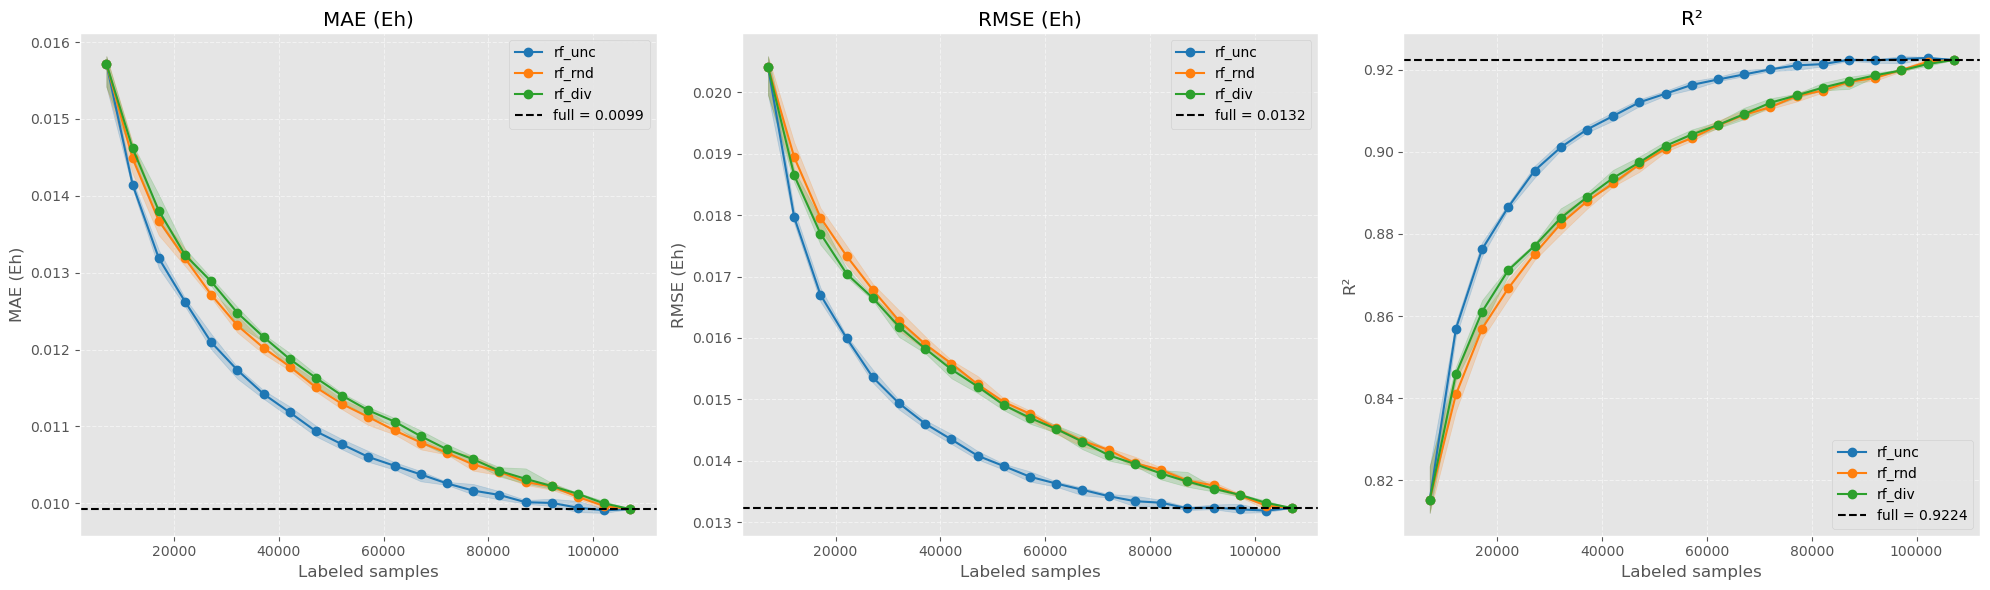

In [35]:
plot_al([rf_unc, rf_rnd, rf_div], ['rf_unc', 'rf_rnd', 'rf_div'], rf_score, 'active_learning/rf/qm9/al_rf_gap_qm9.png', format='png')

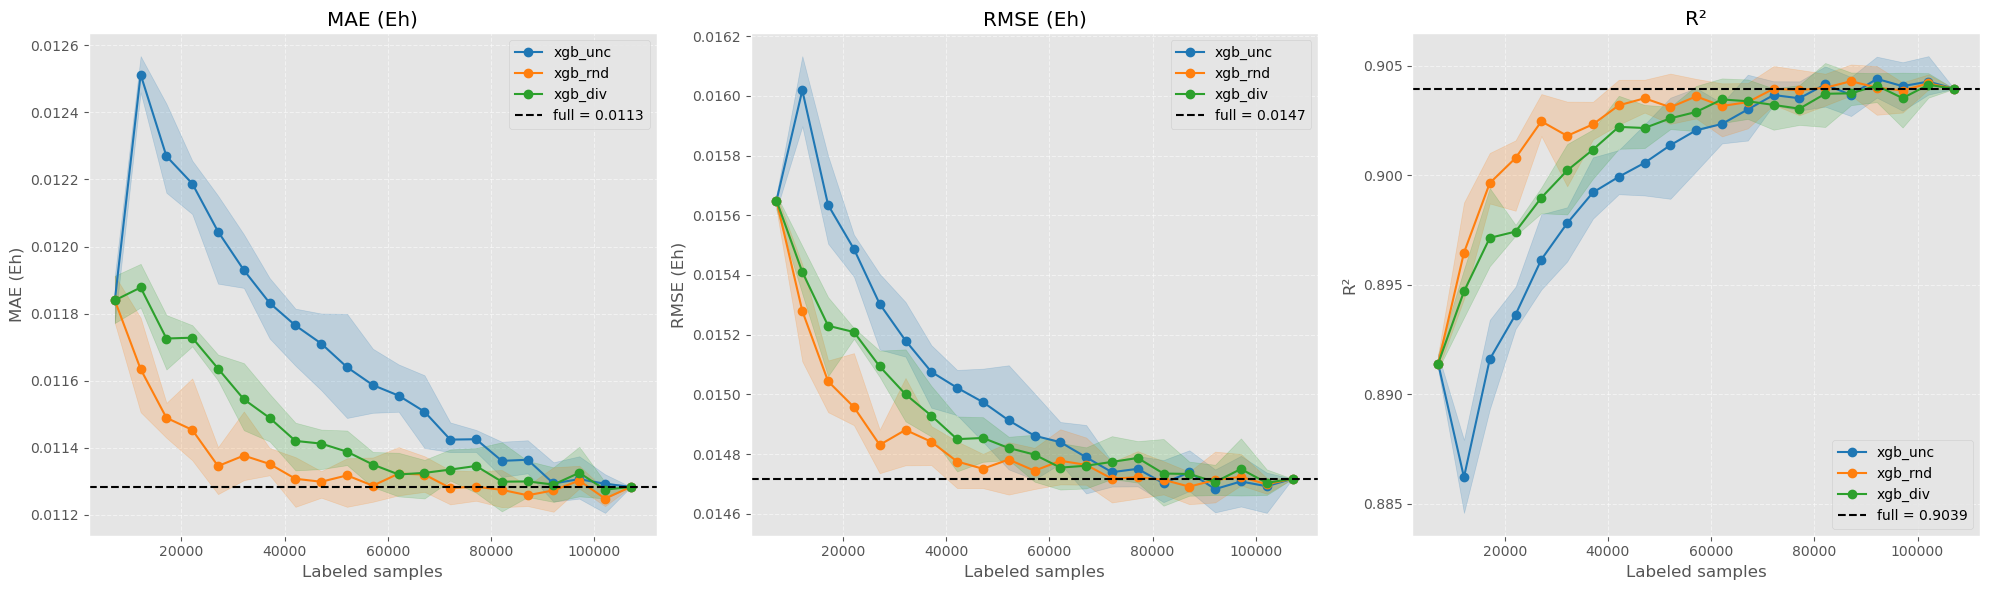

In [36]:
plot_al([xgb_unc, xgb_rnd, xgb_div], ['xgb_unc', 'xgb_rnd', 'xgb_div'], xgb_score, 'active_learning/xgb/qm9/al_xgb_gap_qm9.png', format='png')

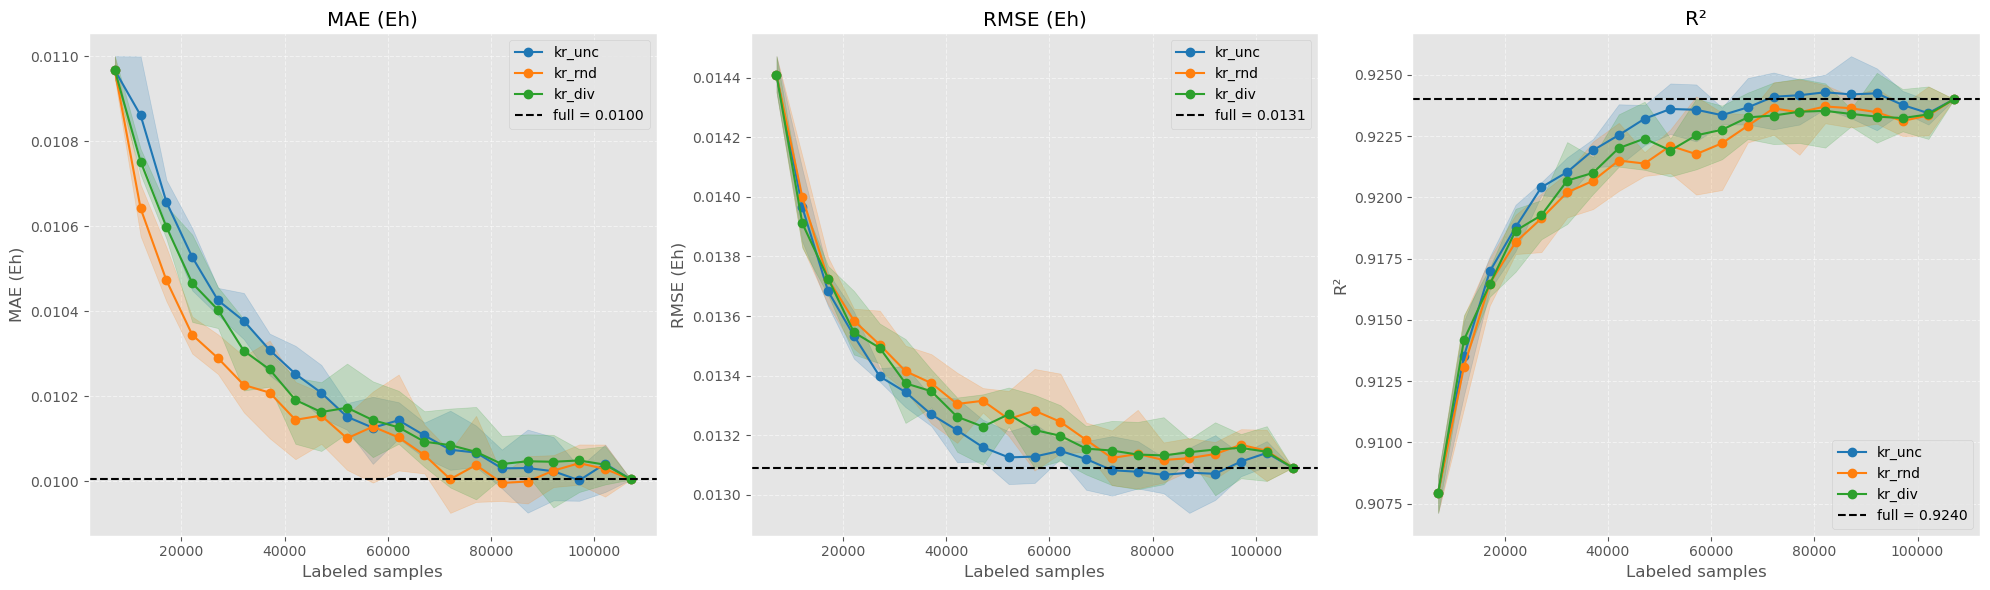

In [37]:
plot_al([kr_unc, kr_rnd, kr_div], ['kr_unc', 'kr_rnd', 'kr_div'], kr_score, 'active_learning/kr/qm9/al_kr_gap_qm9.png', format='png')

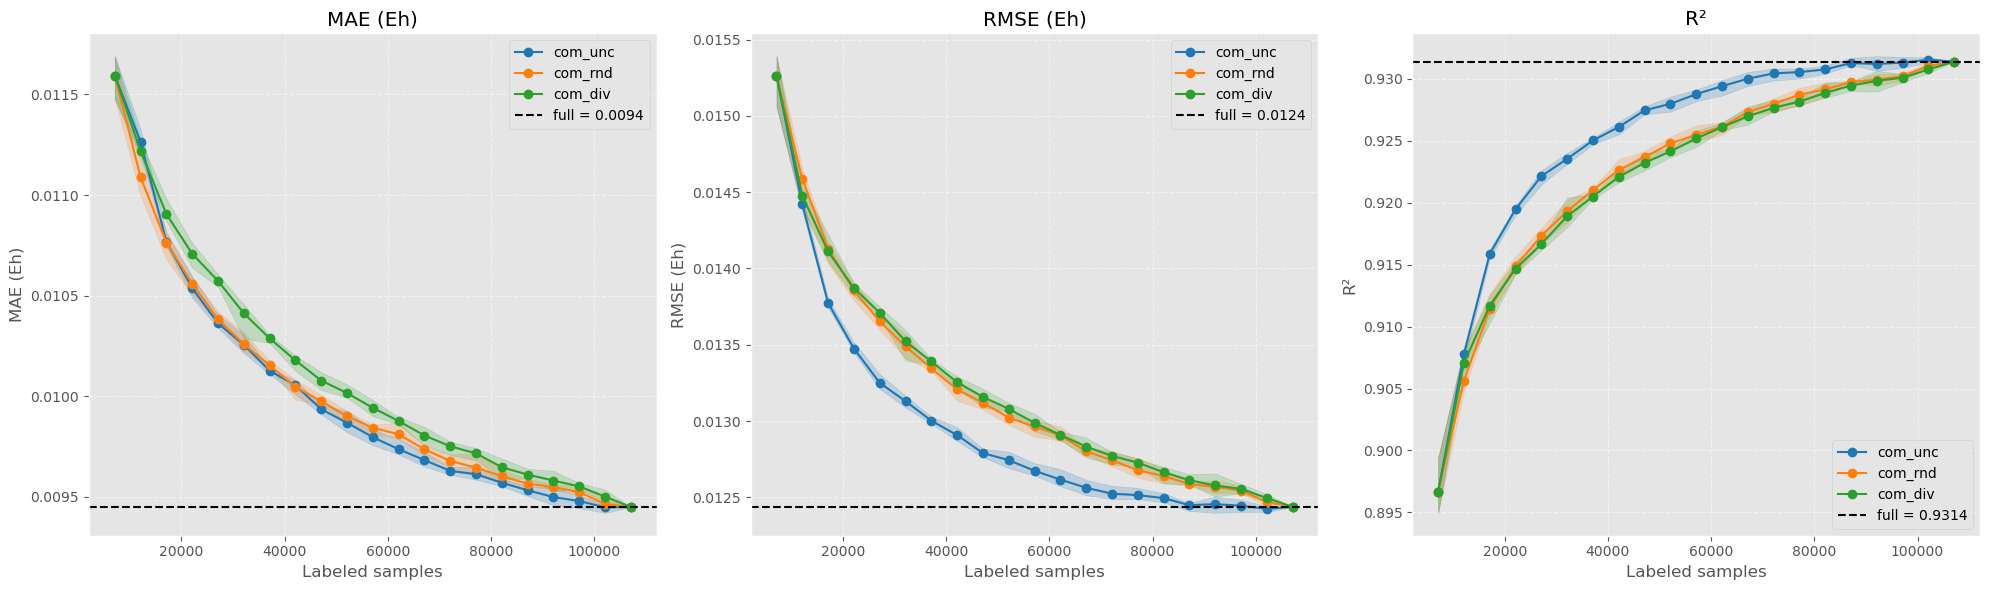

In [38]:
plot_al([com_unc, com_rnd, com_div], ['com_unc', 'com_rnd', 'com_div'], com_score, 'active_learning/com/qm9/al_com_gap_qm9.png', format='png')

In [15]:
import ast
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

print('Computing UMAP projection for X_train...')

reducer = umap.UMAP(
    n_neighbors=25, 
    min_dist=0.05, 
    metric='jaccard', 
    random_state=42
)
X_umap = reducer.fit_transform(X_train)
# X_umap = reducer.fit_transform(X_train[:, (slice(len(qm9_features), None))])

print('UMAP Projection complete.')

Computing UMAP projection for X_train...
UMAP Projection complete.


In [25]:
import ast
import glob
import os
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import imageio.v2 as imageio

# ── PARAMETERS & CONFIGURATION ────────────────────────────────────────────────
CSV_PATH = 'active_learning/com/qm9/al_history_com_div_gap_qm9.csv'
FRAME_DIR = 'temp_al_frames'
GIF_OUTPUT = 'active_learning/com/qm9/umap_al_com_div_gap_qm9.gif'
TARGET_RUN = 1
FPS = 1.5 # Frames per second for the output GIF

# ── LOAD AND PREPROCESS DATA ──────────────────────────────────────────────────
results_df = pd.read_csv(CSV_PATH)
run_df = results_df[results_df['run'] == TARGET_RUN].sort_values('cycle')

# Parse CSV stringified lists back into Python lists
parsed_cycles = []
for idx, row in run_df.iterrows():
    raw_indices = row['queried_idx']
    if isinstance(raw_indices, str):
        indices_list = ast.literal_eval(raw_indices)
    else:
        indices_list = raw_indices
    parsed_cycles.append((int(row['cycle']), indices_list))

# ── MAIN ANIMATION LOOP ───────────────────────────────────────────────────────
frame_files = []

for i, (current_cycle, current_batch) in enumerate(parsed_cycles):
    # Retrieve and separate historically labeled vs. newly queried points
    previous_indices = []
    for cycle_num, indices in parsed_cycles[:i]:
        previous_indices.extend(indices)
    
    total_labeled_count = len(previous_indices) + len(current_batch)

    # Initialize a perfect square canvas
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    
    # Layer 1: Background Density Map (Log scaled)
    hb = ax.hexbin(
        X_umap[:, 0],
        X_umap[:, 1],
        gridsize=60,
        cmap='copper_r',
        mincnt=1,
        edgecolors='none',
        norm=colors.LogNorm()
    )

    # Layer 2: Previously Labeled points (Colored by ground-truth property)
    sc = ax.scatter(
        X_umap[previous_indices, 0],
        X_umap[previous_indices, 1],
        c=y_train[previous_indices],
        cmap='viridis',
        vmin=0.0,
        vmax=0.7,
        marker='o',
        edgecolors='none',
        s=10,
        alpha=0.7,
        label='Previously Labeled',
    )

    # Layer 3: Newly Labeled Points (A acquisition target highlighted in pink)
    ax.scatter(
        X_umap[current_batch, 0],
        X_umap[current_batch, 1],
        c='#FF0055',
        marker='o',
        s=4,
        alpha=0.5,
        label='Newly Labeled',
    )

    # Align 1:1 coordinate spans to keep the physical aspect ratio square
    x_min, x_max = X_umap[:, 0].min(), X_umap[:, 0].max()
    y_min, y_max = X_umap[:, 1].min(), X_umap[:, 1].max()
    limit_min = min(x_min, y_min) - 0.5
    limit_max = max(x_max, y_max) + 0.5
    
    ax.set_xlim(limit_min, limit_max)
    ax.set_ylim(limit_min, limit_max)
    ax.set_aspect('equal', adjustable='box')

    # Position colorbars using relative canvas coordinates
    ax_cb_horizontal = ax.inset_axes([0.1, -0.07, 0.8, 0.03])
    cb_density = fig.colorbar(hb, cax=ax_cb_horizontal, orientation='horizontal')
    cb_density.set_label('Molecule Density (Count per Hex)', fontsize=10, fontweight='bold')
    
    ax_cb_vertical = ax.inset_axes([1.03, 0.1, 0.03, 0.8])
    cb_gap = fig.colorbar(sc, cax=ax_cb_vertical)
    cb_gap.set_label('HOMO-LUMO Gap (eV)', fontsize=10, fontweight='bold')

    # Titles and Legends
    ax.set_title(
        f'QM9 Chemical Space (UMAP)\n'
        f'Run {TARGET_RUN} | Cycle {current_cycle} | {total_labeled_count} Total Labeled',
        fontsize=13,
        fontweight='bold',
        pad=15
    )
    
    ax.legend(
        loc='upper right', 
        scatterpoints=1, 
        markerscale=1.5, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=9
    )

    # plt.show()
    # Save current cycle plot frame
    frame_path = os.path.join(FRAME_DIR, f'frame_{current_cycle:03d}.png')
    plt.savefig(frame_path, dpi=150) # Use 150 DPI for faster writing
    plt.close(fig)
    
    frame_files.append(frame_path)
    print(f'Rendered Frame for Cycle {current_cycle}')

# ── STEP 5: COMPILING INDIVIDUAL FRAMES INTO A GIF ───────────────────────────
print("Compiling global GIF animation...")
images = [imageio.imread(f) for f in frame_files]
imageio.mimsave(GIF_OUTPUT, images, fps=FPS)

# Optional cleanup: Delete temporary PNG frame files
for f in frame_files:
    os.remove(f)

print(f"Success! Saved evolution animation to: '{GIF_OUTPUT}'")

Rendered Frame for Cycle 1
Rendered Frame for Cycle 2
Rendered Frame for Cycle 3
Rendered Frame for Cycle 4
Rendered Frame for Cycle 5
Rendered Frame for Cycle 6
Rendered Frame for Cycle 7
Rendered Frame for Cycle 8
Rendered Frame for Cycle 9
Rendered Frame for Cycle 10
Rendered Frame for Cycle 11
Rendered Frame for Cycle 12
Rendered Frame for Cycle 13
Rendered Frame for Cycle 14
Rendered Frame for Cycle 15
Rendered Frame for Cycle 16
Rendered Frame for Cycle 17
Rendered Frame for Cycle 18
Rendered Frame for Cycle 19
Rendered Frame for Cycle 20
Rendered Frame for Cycle 21
Compiling global GIF animation...
Success! Saved evolution animation to: 'active_learning/com/qm9/umap_al_com_div_gap_qm9.gif'


## Random Sampling

## Uncertainty Sampling

## Diversity based sampling

### Tanimoto similarity

## QBC

# Results

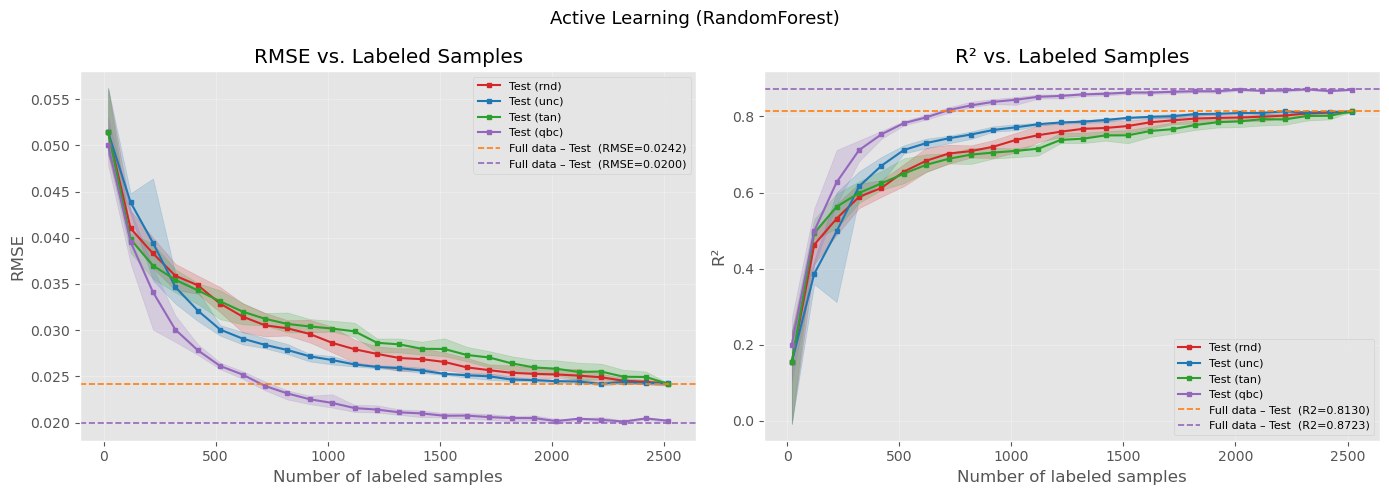

In [89]:
plt_train = False
plt_test = True
plt_val = False

# ── visualisation ─────────────────────────────────────────────────────────────
n = np.array(history_rnd[0]['history']['n_labeled'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Active Learning (RandomForest)', fontsize=13)

# --- RMSE ---
ax = axes[0]
# ax.set_xscale('log')
if plt_train:
    ax.plot(n, history_rnd['train_rmse'], 'o-',  ms=3, lw=1.5, label='Train (rnd)', color='tab:red',)
    ax.plot(n, history_unc['train_rmse'], 'o-.',  ms=3, lw=1.5, label='Train (unc)', color='tab:red',)
    ax.plot(n, history_tan['train_rmse'], 'o:',  ms=3, lw=1.5, label='Train (tan)', color='tab:red',)
    ax.axhline(rf_score['train_rmse'],  color='tab:red',  ls='--', lw=1.2,
               label=f'Full data – Train   (RMSE={rf_score['train_rmse']:.4f})')

if plt_test:
    y_rnd = np.array([run['history']['test_rmse'] for run in history_rnd], dtype=float)
    ax.plot(n, y_rnd.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (rnd)', color='tab:red', )
    ax.fill_between(n, y_rnd.min(axis=0), y_rnd.max(axis=0), color='tab:red', alpha=0.2,)

    y_unc = np.array([run['history']['test_rmse'] for run in history_unc], dtype=float)
    ax.plot(n, y_unc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (unc)', color='tab:blue', )
    ax.fill_between(n, y_unc.min(axis=0), y_unc.max(axis=0), color='tab:blue', alpha=0.2,)

    y_tan = np.array([run['history']['test_rmse'] for run in history_tan], dtype=float)
    ax.plot(n, y_tan.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (tan)', color='tab:green', )
    ax.fill_between(n, y_tan.min(axis=0), y_tan.max(axis=0), color='tab:green', alpha=0.2,)

    y_qbc = np.array([run['history']['test_rmse'] for run in history_qbc], dtype=float)
    ax.plot(n, y_qbc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (qbc)', color='tab:purple', )
    ax.fill_between(n, y_qbc.min(axis=0), y_qbc.max(axis=0), color='tab:purple', alpha=0.2,)
    
    ax.axhline(rf_score['test_rmse'], color='tab:orange', ls='--', lw=1.2,
               label=f'Full data – Test  (RMSE={rf_score['test_rmse']:.4f})')

    ax.axhline(committee_score['test_rmse'], color='tab:purple', ls='--', lw=1.2,
               label=f'Full data – Test  (RMSE={committee_score['test_rmse']:.4f})')
    
if plt_val:
    ax.plot(n, history_rnd['val_rmse'],   '^-',  ms=3, lw=1.5, label='Val (rnd)', color='tab:green')    
    ax.plot(n, history_unc['val_rmse'],   '^-.',  ms=3, lw=1.5, label='Val (unc)', color='tab:green')    
    ax.plot(n, history_tan['val_rmse'],   '^:',  ms=3, lw=1.5, label='Val (tan)', color='tab:green')               
    ax.axhline(rf_score['val_rmse'],  color='tab:green',  ls='--', lw=1.2,
               label=f'Full data – Val   (RMSE={rf_score['val_rmse']:.4f})')

ax.set_xlabel('Number of labeled samples')
ax.set_ylabel('RMSE')
ax.set_title('RMSE vs. Labeled Samples')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- R² ---
ax = axes[1]

if plt_train:
    ax.plot(n, history_rnd['train_r2'], 'o-',  ms=3, lw=1.5, label='Train (rnd)', color='tab:red',)
    ax.plot(n, history_unc['train_r2'], 'o-.',  ms=3, lw=1.5, label='Train (unc)', color='tab:red',)
    ax.plot(n, history_tan['train_r2'], 'o:',  ms=3, lw=1.5, label='Train (tan)', color='tab:red',)
    ax.axhline(rf_score['train_r2'],  color='tab:red',  ls='--', lw=1.2,
               label=f'Full data – Train   (RMSE={rf_score['train_r2']:.4f})')

if plt_test:
    y_rnd = np.array([run['history']['test_r2'] for run in history_rnd], dtype=float)
    ax.plot(n, y_rnd.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (rnd)', color='tab:red', )
    ax.fill_between(n, y_rnd.min(axis=0), y_rnd.max(axis=0), color='tab:red', alpha=0.2,)

    y_unc = np.array([run['history']['test_r2'] for run in history_unc], dtype=float)
    ax.plot(n, y_unc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (unc)', color='tab:blue', )
    ax.fill_between(n, y_unc.min(axis=0), y_unc.max(axis=0), color='tab:blue', alpha=0.2,)
    
    y_tan = np.array([run['history']['test_r2'] for run in history_tan], dtype=float)
    ax.plot(n, y_tan.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (tan)', color='tab:green', )
    ax.fill_between(n, y_tan.min(axis=0), y_tan.max(axis=0), color='tab:green', alpha=0.2,)
    
    y_qbc = np.array([run['history']['test_r2'] for run in history_qbc], dtype=float)
    ax.plot(n, y_qbc.mean(axis=0),  's-',  ms=3, lw=1.5, label='Test (qbc)', color='tab:purple', )
    ax.fill_between(n, y_qbc.min(axis=0), y_qbc.max(axis=0), color='tab:purple', alpha=0.2,)
    
    ax.axhline(rf_score['test_r2'], color='tab:orange', ls='--', lw=1.2,
               label=f'Full data – Test  (R2={rf_score['test_r2']:.4f})')

    ax.axhline(committee_score['test_r2'], color='tab:purple', ls='--', lw=1.2,
               label=f'Full data – Test  (R2={committee_score['test_r2']:.4f})')

if plt_val:
    ax.plot(n, history_rnd['val_r2'],   '^-',  ms=3, lw=1.5, label='Val (rnd)', color='tab:green')    
    ax.plot(n, history_unc['val_r2'],   '^-.',  ms=3, lw=1.5, label='Val (unc)', color='tab:green')    
    ax.plot(n, history_tan['val_r2'],   '^:',  ms=3, lw=1.5, label='Val (tan)', color='tab:green')               
    ax.axhline(rf_score['val_r2'],  color='tab:green',  ls='--', lw=1.2,
               label=f'Full data – Val   (RMSE={rf_score['val_r2']:.4f})')

ax.set_xlabel('Number of labeled samples')
ax.set_ylabel('R²')
ax.set_title('R² vs. Labeled Samples')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('al_strat_comparison_1.png', dpi=150, bbox_inches='tight')
plt.show()